In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import time

# Find path to test dataset
os.chdir("/obs/dtibi/STL-Dev/STL_main/")
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../" + os.path.basename(PARENT_DIR) + DATA_TEST_PATH.split(os.path.basename(PARENT_DIR))[-1]
)

from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch

Parent directory added to sys.path: .../STL-Dev
Dataset directory used: .../STL-Dev/data/test


In [2]:
# Load target map
s_U, s_Q, d_I = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:3, :, :]
s_U = torch.from_numpy(s_U).float() # Target map of the U component
s_Q = torch.from_numpy(s_Q).float() # Target map of the Q component
d_I = torch.from_numpy(d_I).float() # Ancillary data

# Build ensemble of contamination maps
N = 100
H, W = s_U.shape
c_U = torch.randn(N + 1, H, W) * (0.5**0.5)
c_Q = torch.randn(N + 1, H, W) * (0.5**0.5)

# Observed maps
d_U = s_U + c_U[0] # Observed map of the U component
d_Q = s_Q + c_Q[0] # Observed map of the Q component

In [ ]:
target_maps = torch.stack([d_U, d_Q, d_I], dim=0).unsqueeze(0).repeat(N, 1, 1, 1) # [N, 3, H, W]

running_maps = torch.stack([d_U.clone(), d_Q.clone(), d_I.clone()], dim=0) # [3, H, W]
running_maps.requires_grad_()    

mask = torch.ones_like(running_maps)
mask[2, :, :] = 0  # freeze d_I

running_maps.register_hook(lambda grad: grad * mask)

optimizer = torch.optim.LBFGS(
    [running_maps],
    lr=1,
    max_iter=25,
    tolerance_grad=1e-17,
    tolerance_change=1e-17,
    history_size=100,
    line_search_fn="strong_wolfe",
)

loss_history = []
print_iter = 10

def stats_flatten(data, st_op, norm, precomputed_data_l1=False):
    """
    data : StlData or Dict of StlData
        - If precomputed_data_l1=False : StlData raw data
        - If precomputed_data_l1=True  : Dictionary with integer keys/scale j in [0, J-1] and values StlData wavelet transform at resolution j_to_dg[j]
    """
    return st_op.apply(data, norm=norm, precomputed_data_l1=precomputed_data_l1).to_flatten(keep_batch_dim=True)


with torch.no_grad():

    stl_target_maps = STL_2D_FFT_Torch(target_maps, pbc=True)
    st_op = stl_target_maps.get_ST_op()
    stats_target_maps = stats_flatten(stl_target_maps, st_op, norm="store_ref") # [N, n_stats]

    # Compute wavelet transform of contamination maps once for the entire optimization
    contamination_maps = torch.cat([ 
        c_U[1:].unsqueeze(1), 
        c_Q[1:].unsqueeze(1), 
        torch.zeros_like(c_U[1:]).unsqueeze(1)],
        dim=1
    ) # [N, 3, H, W]
    
    stl_contamination_maps = STL_2D_FFT_Torch(
        contamination_maps,
        pbc=True
    )

    W_contamination_maps = {
        j: st_op.wavelet_op.apply(
            st_op.wavelet_op.downsample(
                data=stl_contamination_maps,
                dg_out=st_op.wavelet_op.j_to_dg[j],
                inplace=False,
                replace_nan_value=st_op.replace_nan_value,
            ),
            j=j
        )
        for j in range(st_op.J)
    } # {j: [N, 3, L, Nj]}

def closure():
    optimizer.zero_grad()

    # Compute wavelet transform of running maps once at each iteration
    rm = torch.cat([
        running_maps[0].unsqueeze(1),
        running_maps[1].unsqueeze(1),
        d_I.unsqueeze(1),
    ], dim=1) # [3, H, W]

    stl_running_maps = STL_2D_FFT_Torch(rm, pbc=True)

    W_running_maps = {
        j: st_op.wavelet_op.apply(
            st_op.wavelet_op.downsample(
                data=stl_running_maps,
                dg_out=st_op.wavelet_op.j_to_dg[j],
                inplace=False,
                replace_nan_value=st_op.replace_nan_value,
            ),
            j=j
        )
        for j in range(st_op.J)
    } # {j: [3, L, Nj]}

    # Broadcast wavelet transform of running maps to the ensemble of contamination maps
    W_running_maps = {
        j: v.unsqueeze(0).repeat(N, 1, 1, 1)
        for j, v in W_running_maps.items()
    } # {j: [N, 3, L, Nj]}


    W_running_maps_plus_contamination = {
        j: W_running_maps[j] + W_contamination_maps[j]
        for j in range(st_op.J)
    } # {j: [N, 3, L, Nj]}

    stats_running_plus_contamination_maps = stats_flatten(
        W_running_maps_plus_contamination,
        norm="load_ref",
        precomputed_data_l1=True,
    ) # [N, n_stats]

    loss = (stats_running_plus_contamination_maps - stats_target_maps).abs().square().sum(dim=1).mean()
    
    loss.backward()
    loss_history.append(loss.item())

    if len(loss_history) % print_iter == 0:
        print(f"[LBFGS] iter {len(loss_history)}, loss = {loss.item():.6e}")

    return loss

start = time.perf_counter()
optimizer.step(closure)
end = time.perf_counter() 

print(f"{len(loss_history)} iterations of synthesis.")
print(f"Execution time: {end - start:.3f} s")

running_maps = running_maps.detach()

[LBFGS] iter 10, loss = 6.507978e+00
[LBFGS] iter 20, loss = 5.305980e-01
[LBFGS] iter 30, loss = 3.663310e-01
31 iterations of synthesis.
Execution time: 77.978 s


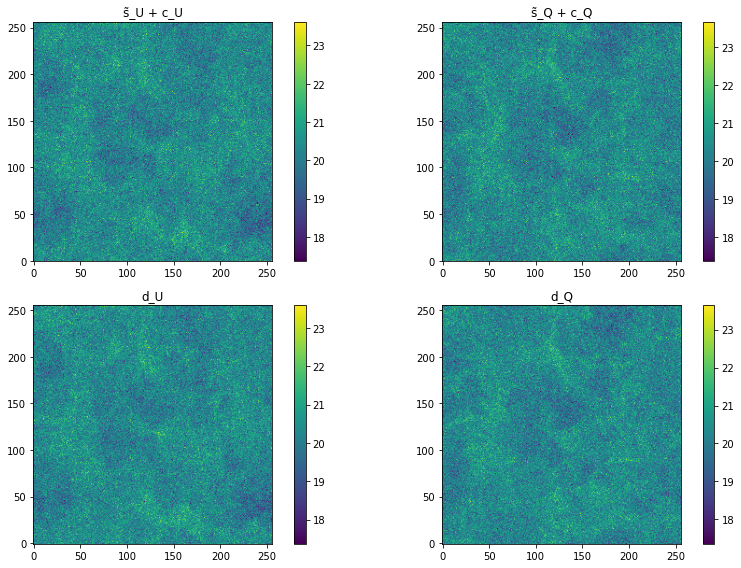

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- U reference scale ---
vmin_U = d_U.min()
vmax_U = d_U.max()

# s_U + c_U (same scale as d_U)
im0 = axes[0, 0].imshow(running_maps[0] + c_U[4],
                        origin="lower",
                        vmin=vmin_U,
                        vmax=vmax_U)
axes[0, 0].set_title("s̃_U + c_U")
plt.colorbar(im0, ax=axes[0, 0])

# d_U (reference)
im1 = axes[1, 0].imshow(d_U,
                        origin="lower",
                        vmin=vmin_U,
                        vmax=vmax_U)
axes[1, 0].set_title("d_U")
plt.colorbar(im1, ax=axes[1, 0])


# --- Q reference scale ---
vmin_Q = d_Q.min()
vmax_Q = d_Q.max()

# s_Q + c_Q (same scale as d_Q)
im2 = axes[0, 1].imshow(running_maps[1] + c_Q[4],
                        origin="lower",
                        vmin=vmin_Q,
                        vmax=vmax_Q)
axes[0, 1].set_title("s̃_Q + c_Q")
plt.colorbar(im2, ax=axes[0, 1])

# d_Q (reference)
im3 = axes[1, 1].imshow(d_Q,
                        origin="lower",
                        vmin=vmin_Q,
                        vmax=vmax_Q)
axes[1, 1].set_title("d_Q")
plt.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()
plt.show()